**<h1 align="center">  Modelagem de Tópicos</h1>**
___

## **1. Importando as boas transcrições**

In [1]:
import os
import pandas as pd

DIR_TRANSCRIPTIONS = '../../transcriptions'

data = []

for file in os.listdir(DIR_TRANSCRIPTIONS): # retorna uma lista com os nomes de tudo que esta dentro de DIR_TRANSCRIPTIONS
    if os.path.isfile(os.path.join(DIR_TRANSCRIPTIONS,file)): # verifica se o caminho aponta para um arquivo existente
        file_path = os.path.join(DIR_TRANSCRIPTIONS,file) # caminho de cada file
        try:
            with open(file_path,'r') as f:
                text = f.read()
                id = file.replace('.txt','')
                data.append({'id': id, 'text': text}) # guarda o id do vídeo e a transcrição nele presente
        except Exception as e:
            print(f"Erro ao ler o arquivo {file}: {e}")

df = pd.DataFrame(data)
display(df)

,id,text
0,P4VjVG3lt1E,e aí e bora aí galera fiz um vídeozinho peque...
1,cfDBwrkINHo,Fala rapaziada mano pega a visão vem aqui pra...
2,URw3_PM_mhs,"Olá a todos, fala que Marcelo Lisboa sejam be..."
3,Tn6X9lKvM9Q,tal rapaziada beleza que quem fala que vocês ...
4,C3pjP175-Uk,fala minha tropinha e como é que vocês estão ...
...,...,...
1952,WJNbIUAmbMU,"Fala galera, passando no início aqui do vídeo..."
1953,80r3-jnvywA,"Eu sou eu, sou eu Eu via no rádio de pilha um..."
1954,bpKtV5F96fc,"Fala galera, tudo bom com vocês? Como vocês e..."
1955,YJZbmcaShFU,Fizemos a parte de um dos mais importantes. A...


In [2]:
# Selecionando apenas as transcrições boas

FILE_IDS = '../../filtrated_data_log/ids_transcricoes_boas.csv'
FILE_BOAS_TRANSCRICOES = '../../filtrated_data_log/transcricoes_boas.csv'

ids_boas_transcricoes = pd.read_csv(FILE_IDS)

df = df[df['id'].isin(ids_boas_transcricoes['arquivo'])].copy()

#Guardando as boas transcrições em um csv
df.to_csv(FILE_BOAS_TRANSCRICOES, index=False)

ids_que_nao_entraram = ids_boas_transcricoes[~ids_boas_transcricoes['arquivo'].isin(df['id'])]
print(f"Este(s) id(s) não entrou(aram): {ids_que_nao_entraram['arquivo'].to_list()}")
print(len(df))

Este(s) id(s) não entrou(aram): ['aF6js6vqGeo']
1067


___
## **2. Análises Básicas**

#### Quantidade de palavras por transcrição

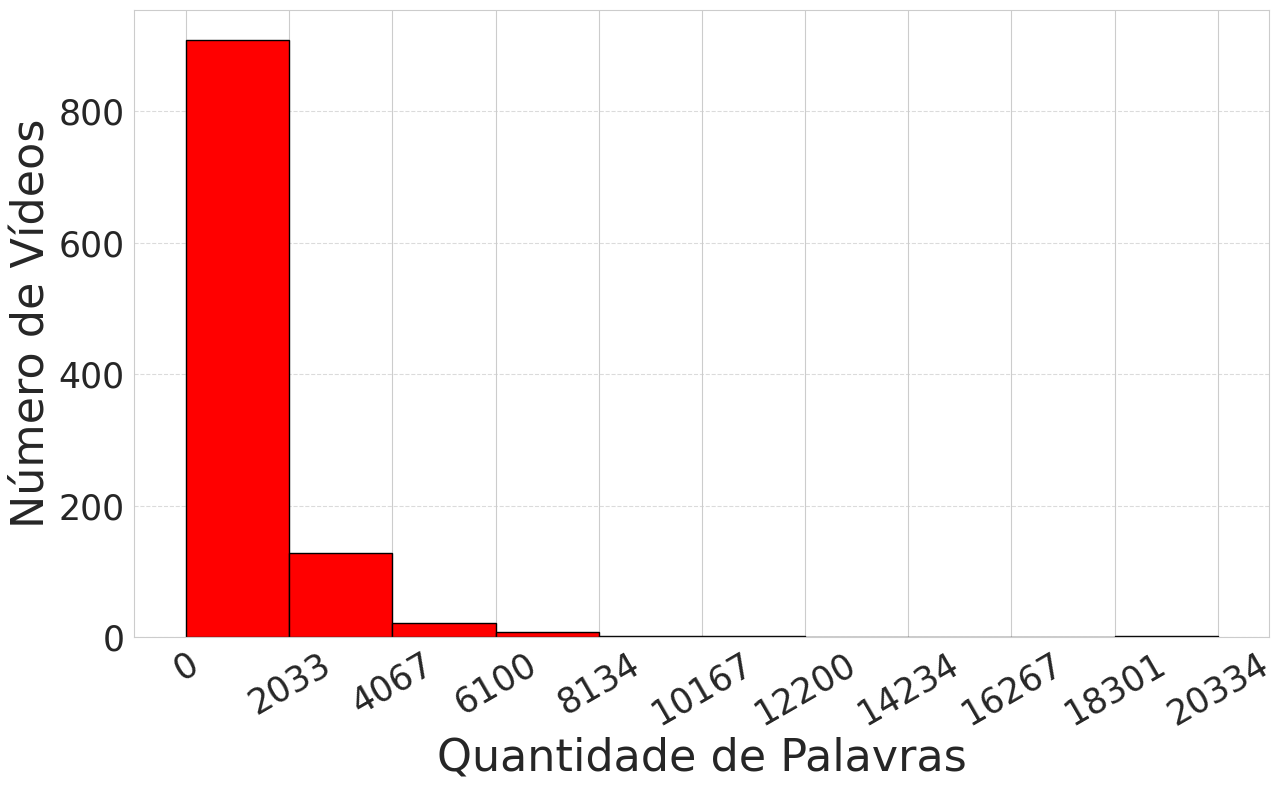

In [21]:
import matplotlib.pyplot as plt
import numpy as np

df["Word_count"] = df["text"].apply(lambda x: len(x.split()))  # Número de palavras por documento

plt.figure(figsize=(13, 8))
n, bins_edges, patches = plt.hist(df["Word_count"], bins=10, color='red', edgecolor='black')

plt.xticks(bins_edges)  # Alinhando os ticks com os limites dos bins

plt.xlabel('Quantidade de Palavras', fontsize=32)
plt.ylabel('Número de Vídeos', fontsize=32)
plt.xticks(rotation=30,fontsize=25)
plt.yticks(fontsize=25)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Quantidade de textos na primeira barra: 909


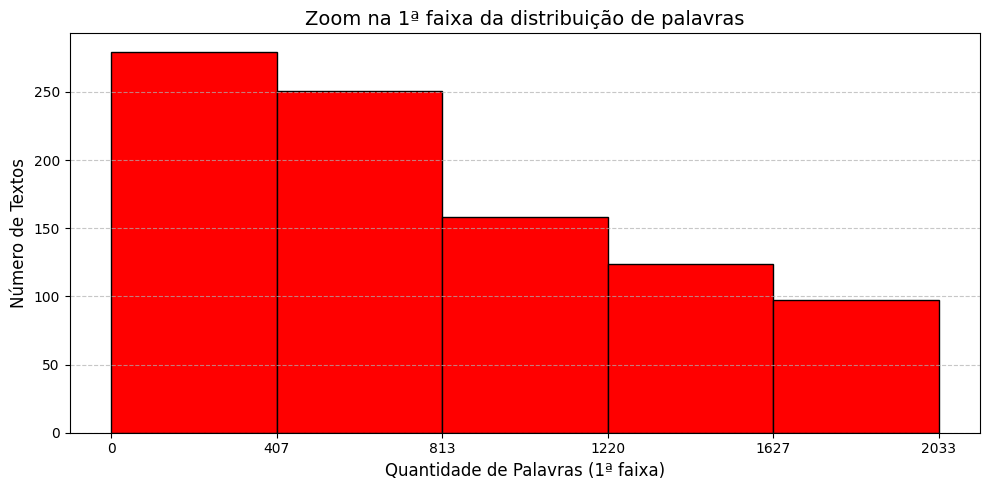

In [4]:
#filtrar apenas os textos da 1ª barra
lim_inf = bins_edges[0]
lim_sup = bins_edges[1]

primeira_barra = df[(df["Word_count"] >= lim_inf) & (df["Word_count"] < lim_sup)]
print(f"Quantidade de textos na primeira barra: {len(primeira_barra)}")

plt.figure(figsize=(10, 5))
bins = np.linspace(0, lim_sup, 6)
plt.hist(primeira_barra["Word_count"], bins=bins, color='red', edgecolor='black')

plt.xticks(bins)  # Alinha as marcações do eixo X com os limites dos bins

plt.xlabel('Quantidade de Palavras (1ª faixa)', fontsize=12)
plt.ylabel('Número de Textos', fontsize=12)
plt.title('Zoom na 1ª faixa da distribuição de palavras', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Estatísticas Básicas

In [5]:
df["Word_count"].describe()
# Count: número de mensagens
# Mean: média de palavras por mensagem
# Std: desvio padrão (o quanto as mensagens variam em relação à média)
# Min: a menor mensagem tem nenhuma palavra
# 25%: 25% das mensagens têm até 468 palavras
# Max: a maior mensagem tem 20334 palavras

count     1067.000000
mean      1162.115276
std       1299.343448
min          0.000000
25%        378.000000
50%        822.000000
75%       1586.500000
max      20334.000000
Name: Word_count, dtype: float64

In [6]:
# Transcrições com zero palavras

transcricoes_vazias = df[df['Word_count'] == 0]
print(f"Transcrições com zero palavras: {len(transcricoes_vazias)}")
print("IDs dos vídeos com transcrição vazia:")
print(transcricoes_vazias['id'].tolist())

Transcrições com zero palavras: 6
IDs dos vídeos com transcrição vazia:
['SKzCWxjxqk4', 'GPaVW3dN3Ws', 'aOAgOqnctRo', 'Bsx6d-_dlJ4', 'v7VBGT7pzKM', 'eW3EPPLRqY0']


___
## **3. Pré-Processamento**

#### Encontrando stop words

In [ ]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

from PreProcessing import PreProcessing
import numpy as np
import spacy as sp

def remove_repetion_caracteres(string, max_repetition=2):
    if not string:
        return string
    
    result = string[0]
    count = 1
    
    for i in range(1, len(string)):
        if string[i] == string[i-1]:
            count += 1
            if count <= max_repetition:
                result += string[i]
        else:
            count = 1
            result += string[i]
    
    return result

def preprocess_text_pipeline(#input_csv_path='./data/dataFrame.csv', 
                              #output_csv_path='./data/dataFrame.csv',
                              df,
                              stopwords_file='stopwords.txt',
                              text_column="comments"):
   
    stem = sp.load("pt_core_news_sm")
    pp = PreProcessing(language="pt")
    
    #Lê cada stopword do stopwords_file e guarda em stopwords_dataset
    stopwords_dataset = [line.strip() for line in open(stopwords_file, 'r').readlines()] 
    # Adiciona à pp.stopwords as novas palavras que estão em stopwords.words('portuguese') e stopwords_dataset
    pp.append_stopwords_list(list(set(stopwords.words('portuguese')) - set(pp.stopwords)) + stopwords_dataset)

    def preprocessing(text):
        if pd.isna(text):
            return np.nan

        tokens = stem(text.lower()) # Processo de lematização da biblioteca spaCy - retorna a lista dos tokens do texto
        text = ' '.join([text for token in tokens for text in token.lemma_.strip().split()]) # Junta estes tokens na ordem do texto bruto
        text = pp.remove_stopwords(text) # Remove stopwords presentes
        text = pp.lowercase_unidecode(text) # Coloca tudo em lowercase e remove acento
        text = pp.remove_stopwords(text) # Remove stopwords presentes 
        text = pp.remove_tweet_marking(text) # Remove @ ou # seguido de 1 ou mais carcteres e n ' ' seguidos
        text = remove_repetion_caracteres(text) # Remove a repetição de caracteres ex: gooool -> gool
        text = pp.remove_urls(text) # Remove http\S+ *, ou seja, qualquer http seguido de 1 ou mais caracteres e os espaços no final
        text = pp.remove_punctuation(text) # Remove os sinais de pontuação e reorganiza os espaços
        text = pp.remove_numbers(text) # Remove os números
        text = pp.remove_n(text, n=3) # Remove palavras de tamanho <= n(n=3)
        
        return text

    #df = pd.read_csv(input_csv_path)
    df['clean_text'] = df[text_column].apply(preprocessing)
    #df.to_csv(output_csv_path, index=False)
    return df

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/webmedia2025/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [8]:
df_clean = preprocess_text_pipeline(df=df, text_column='text')
df_clean["Word_count_clean"] = df_clean["clean_text"].apply(lambda x: len(x.split()))
display(df_clean)

,id,text,Word_count,clean_text,Word_count_clean
0,P4VjVG3lt1E,e aí e bora aí galera fiz um vídeozinho peque...,147,galer videozinho pequeno coloquei tigre fortun...,34
1,cfDBwrkINHo,Fala rapaziada mano pega a visão vem aqui pra...,1545,visao dica investimento botar derrameiro milha...,276
2,URw3_PM_mhs,"Olá a todos, fala que Marcelo Lisboa sejam be...",2517,marcelo lisboa fortuny tiger continuidade seri...,702
6,mmZe9cyM_bs,"eu estou de uma forradinha no off, comecei es...",1088,forradinha banquinha chegar algum minima emine...,239
7,ivZG6TrZLEM,"Olá a todos, fala que Marcelo Lisboa sejam be...",3429,marcelo lisboa fortuny tiger dano continuidade...,899
...,...,...,...,...,...
1948,dNp1axRNEls,"Jogo do Tigrinho, você já ouviu, você já jogo...",828,jogo tigrinho ouvir jogar enrolar jogo tigrinh...,274
1950,pVO5-BA9IYo,"E vemo um doenho ai, beleza? De 100 reais Eit...",533,vemo doenho eito pagar isabel banquinha alavan...,106
1951,mOKM_W4sHzY,Salve Salve meu rapazera beleza? Sejam bem vi...,1909,salver salve rapazera vinr pesar volta fortuny...,437
1954,bpKtV5F96fc,"Fala galera, tudo bom com vocês? Como vocês e...",862,trazer famoso fuller tunetigre tigre jogo paga...,179


In [9]:
from collections import Counter

all_text = " ".join(df_clean['clean_text'])
all_words = [word for word in all_text.split() if word]

vocab = set(all_words)


freq = {}
for text in df['clean_text']:
    words = set(text.split())
    for word in words:
        freq[word] = freq.get(word,0)+1

freq = sorted(freq.items(), key = lambda item : item[1], reverse = True)

print("Top 100 palavras mais frequentes por documento:")
i = 0
for word,freq in freq:
    if i==100: break
    print(f"{word} : {freq}")
    i+=1

Top 100 palavras mais frequentes por documento:
jogar : 699
jogo : 660
ganhar : 619
pagar : 598
algum : 590
banca : 538
comentario : 492
perder : 492
colocar : 484
estrategia : 482
continuar : 475
entrar : 467
hora : 462
esperar : 459
certo : 446
plataforma : 441
ganho : 439
dinheiro : 436
chegar : 433
voltar : 418
carta : 417
parar : 416
passar : 414
gostar : 414
turbo : 411
soltar : 406
entender : 404
lembrar : 400
like : 396
acontecer : 395
valer : 392
sair : 389
acabar : 379
precisar : 378
mostrar : 371
funcionar : 361
quase : 356
rodada : 351
tigre : 348
pouquinho : 347
subir : 347
alto : 346
conta : 333
cartinha : 331
link : 327
tomar : 324
seguinte : 323
lucro : 322
tiger : 319
ajudar : 314
tigrinho : 313
rodar : 311
mundo : 308
aumentar : 307
verdade : 305
junto : 300
fixar : 295
mandar : 289
nenhum : 283
casa : 280
centavo : 276
testar : 275
caso : 272
legal : 272
tirar : 270
bater : 266
modo : 262
giro : 262
pequeno : 253
botar : 252
ativar : 245
girar : 243
tamo : 242
tela :

In [10]:
df_clean.to_csv("dataFrame.csv")
df_clean[['id', 'clean_text']].to_csv("dataFrame_pp.csv", index=False)

___

## **4. Treinando modelo BERTopic**

In [11]:
from topicmodeling import run_topic_modeling

# Executa o BERTopic, definindo os parâmentros e usando o kmeans
#if run_topic_modeling(): print("Modelagem concluída.")
loaded_model = run_topic_modeling()

/home/webmedia2025/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'nr_topics': 5, 'language': 'portuguese', 'calculate_probabilities': True, 'verbose': False, 'top_n_words': 10, 'umap_model': UMAP(metric='cosine', n_components=5, n_neighbors=10, random_state=42), 'hdbscan_model': HDBSCAN(min_cluster_size=50, min_samples=5, prediction_data=True), 'ctfidf_model': ClassTfidfTransformer(reduce_frequent_words=True)}


In [12]:
from meu_bertopic import BERTopic

loaded_model = BERTopic.load(f"./topicmodeling/data_topic_modeling/kmeans_1")

In [13]:
loaded_model.get_topic_info()

,Topic,Count,Name,Representation,Aspect1,Aspect2,Representative_Docs
0,0,208,0_devolver_estrategia_retencao_distribuicao,"[devolver, estrategia, retencao, distribuicao,...","[rodada, slot, banca, jogada, plano, jogador, ...","[devolver, estrategia, retencao, distribuicao,...",[marcelo lisboa fortuny tiger canal banca vers...
1,1,201,1_estrategia_passo_utilizar_ganhar,"[estrategia, passo, utilizar, ganhar, consegui...","[estrategia, turbo, modo, carta, plataforma, r...","[estrategia, passo, utilizar, ganhar, consegui...",[salver salver rapaziada pesar mano tigerzao f...
2,2,97,2_divulgar_brasileiro_brasil_situacao,"[divulgar, brasileiro, brasil, situacao, maran...","[brasil, policia, crime, dinheiro, influenciad...","[divulgar, brasileiro, brasil, situacao, maran...",[espertalhao assunto bombar rede social descob...
3,3,198,3_caramba_fugia_tomar_acabar,"[caramba, fugia, tomar, acabar, conseguir, jei...","[minuto, perfeito, salto, jovem, cartinha, pil...","[caramba, fugia, tomar, acabar, conseguir, jei...",[jama mola mola cartao vermelho deus mola arra...
4,4,278,4_ganho_passar_carar_junto,"[ganho, passar, carar, junto, aparecer, tomar,...","[mano, banca, real, soltar, carta, minuto, gir...","[ganho, passar, carar, junto, aparecer, tomar,...",[rapazer like speak passeiro ligar trazer traz...


In [14]:
lista_de_topicos = list(range(5))
loaded_model.visualize_barchart(topics=lista_de_topicos, n_words=10)

In [15]:
# Gera o heatmap de similaridade
fig_heatmap = loaded_model.visualize_heatmap()
fig_heatmap.show()

In [16]:
loaded_model.visualize_topics()

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

topics_data = loaded_model.get_topics()

num_topicos_para_plotar = 5

for topic_id in range(num_topicos_para_plotar):
    topic_words = topics_data[topic_id][:10]
    df_topic = pd.DataFrame(topic_words, columns=["Palavra", "Score"])
    display(df_topic)

,Palavra,Score
0,devolver,0.467901
1,estrategia,0.438096
2,retencao,0.431723
3,distribuicao,0.420981
4,capacidade,0.415854
5,banca,0.412504
6,jogador,0.410424
7,manter,0.408939
8,conectar,0.401910
9,jogada,0.396940


,Palavra,Score
0,estrategia,0.608333
1,passo,0.485984
2,utilizar,0.480948
3,ganhar,0.479452
4,conseguir,0.479452
5,fixar,0.472234
6,descricao,0.471133
7,lucrar,0.467670
8,soltar,0.466508
9,ajudar,0.464293


,Palavra,Score
0,divulgar,0.506547
1,brasileiro,0.501717
2,brasil,0.487044
3,situacao,0.483951
4,maranhao,0.463230
5,divulgacao,0.461449
6,populacao,0.456858
7,influenciadore,0.453509
8,publico,0.452032
9,influenciador,0.447835


,Palavra,Score
0,caramba,0.571532
1,fugia,0.570447
2,tomar,0.548451
3,acabar,0.548309
4,conseguir,0.539859
5,jeito,0.539014
6,sentir,0.533910
7,grisar,0.524864
8,aplicar,0.522374
9,vamo,0.521327


,Palavra,Score
0,ganho,0.430543
1,passar,0.402813
2,carar,0.397200
3,junto,0.394282
4,aparecer,0.382970
5,tomar,0.377729
6,manter,0.377605
7,soltar,0.369438
8,girar,0.369243
9,tranquilo,0.366177


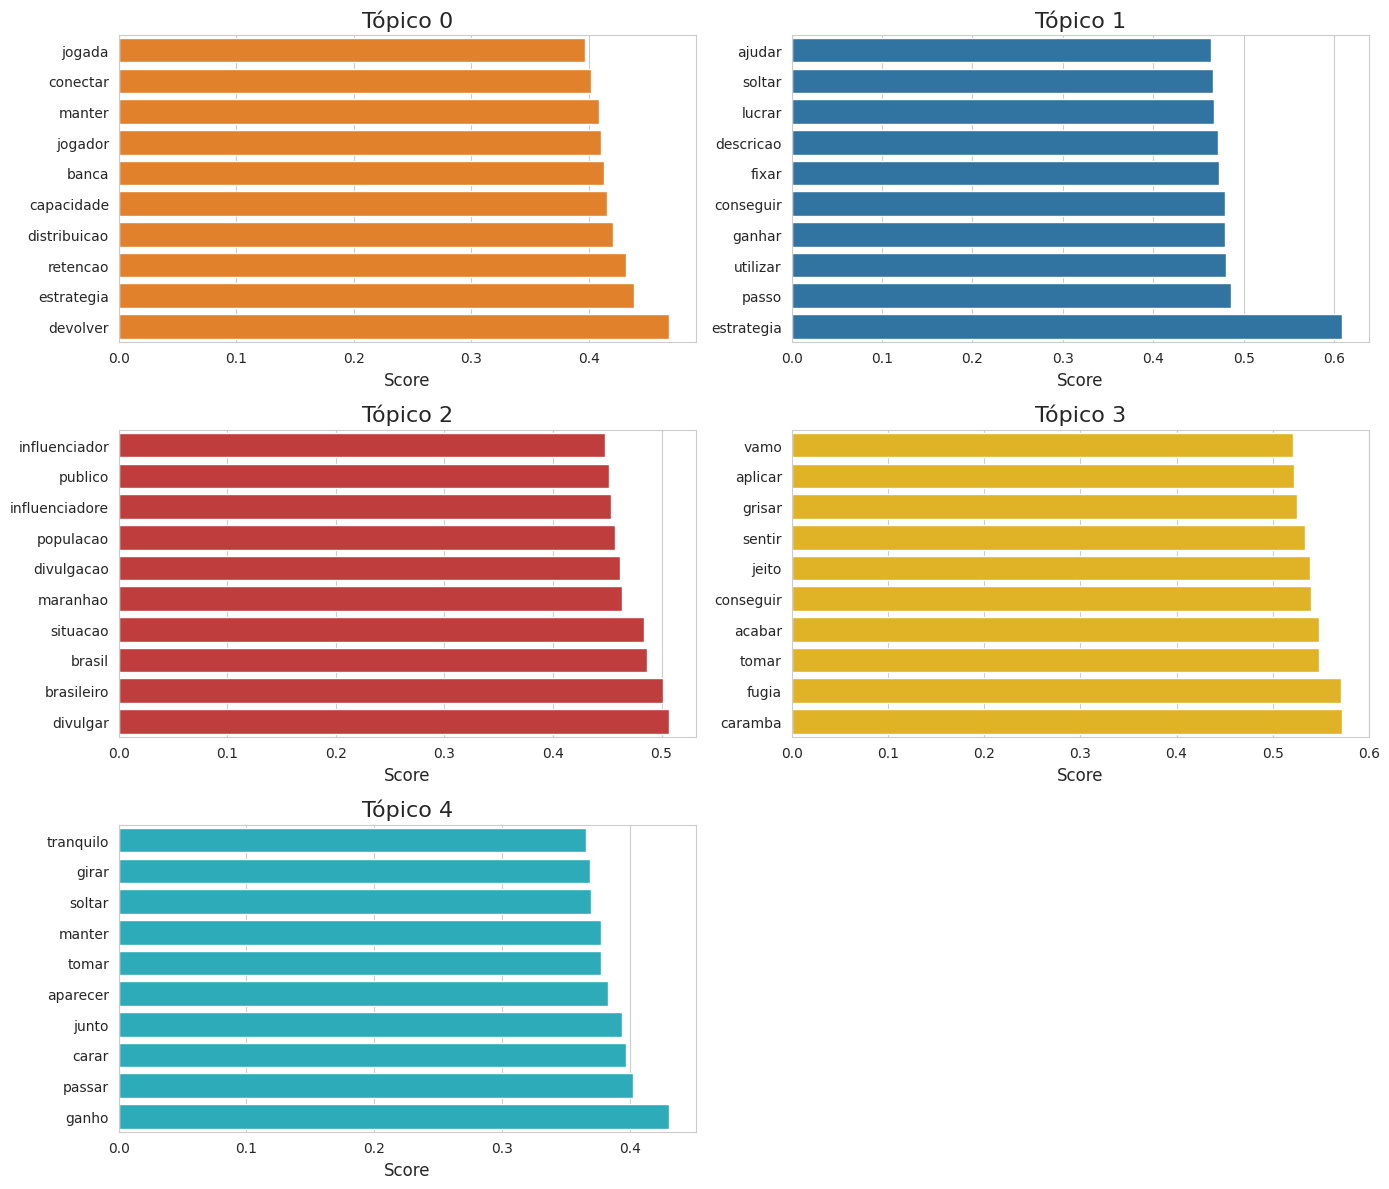

In [18]:
# Seus imports e código inicial (mantidos para contexto)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Supondo que 'loaded_model' já está carregado e tem o método .get_topics()
# topics_data = loaded_model.get_topics()

# --- NOVO CÓDIGO PARA PLOTAR ---

# Define um estilo visual agradável para os gráficos
sns.set_style("whitegrid")

num_topicos_para_plotar = 5
n_palavras = 10

# Cria uma figura e uma grade de subplots (ex: 3 linhas, 2 colunas)
# Ajuste figsize para o tamanho desejado
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# Transforma a matriz 2D de eixos em uma lista 1D para facilitar a iteração
axes = axes.flatten()

# Paleta de cores para replicar o visual do gráfico original
cores = ['#ff7f0e', '#1f77b4', '#d62728', '#ffc107', '#17becf']

for topic_id in range(num_topicos_para_plotar):
    # Pega os dados do tópico (exatamente como você já fez)
    topic_words = loaded_model.get_topics()[topic_id][:n_palavras]
    df_topic = pd.DataFrame(topic_words, columns=["Palavra", "Score"])

    # Seleciona o subplot atual
    ax = axes[topic_id]

    # Cria o gráfico de barras horizontais no subplot selecionado
    # Usamos .iloc[::-1] para inverter a ordem do DataFrame,
    # fazendo com que a palavra de maior score apareça no topo.
    sns.barplot(
        x="Score",
        y="Palavra",
        data=df_topic.iloc[::-1],
        ax=ax,
        color=cores[topic_id % len(cores)] # Usa uma cor diferente para cada tópico
    )

    # Define o título do subplot
    ax.set_title(f"Tópico {topic_id}", fontsize=16)
    
    # Remove o rótulo do eixo Y, pois as palavras já são autoexplicativas
    ax.set_ylabel("")
    ax.set_xlabel("Score", fontsize=12)

# Esconde os subplots que não foram usados (caso o número de tópicos não preencha a grade)
for i in range(num_topicos_para_plotar, len(axes)):
    axes[i].set_visible(False)

# Ajusta o layout para evitar que os títulos e rótulos se sobreponham
plt.tight_layout()

# Mostra o gráfico final
plt.show()